# Customer Reviews Sentiment Analysis & Visualization

In [1]:
# Install if needed
# !pip install pandas nltk textblob matplotlib seaborn wordcloud

In [2]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')
sns.set_style('whitegrid')

[nltk_data] Downloading package punkt to /home/kstubhie/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/kstubhie/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
# Sample data
data = {
    'reviews':[
        'The product quality is very good and delivery was fast',
        'Customer service is very poor and response is slow',
        'I love the design and packaging of the product',
        'The product stopped working after one week',
        'Great experience and affordable price',
        'Bad customer support and late delivery',
        'Excellent features and easy to use',
        'Product quality is average but service is good',
        'Very bad service and poor packaging',
        'Amazing product and fast shipping',
        'Worst product ever and support team not responding',
        'Happy with product and delivery time'
    ]
}

df = pd.DataFrame(data)
df

,reviews
0,The product quality is very good and delivery ...
1,Customer service is very poor and response is ...
2,I love the design and packaging of the product
3,The product stopped working after one week
4,Great experience and affordable price
5,Bad customer support and late delivery
6,Excellent features and easy to use
7,Product quality is average but service is good
8,Very bad service and poor packaging
9,Amazing product and fast shipping


In [4]:
# Preprocessing
stop_words = set(stopwords.words('english'))

def preprocess(text):
    tokens = word_tokenize(text.lower())
    tokens = [w for w in tokens if w.isalpha()]
    tokens = [w for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df['clean_reviews'] = df['reviews'].apply(preprocess)
df

,reviews,clean_reviews
0,The product quality is very good and delivery ...,product quality good delivery fast
1,Customer service is very poor and response is ...,customer service poor response slow
2,I love the design and packaging of the product,love design packaging product
3,The product stopped working after one week,product stopped working one week
4,Great experience and affordable price,great experience affordable price
5,Bad customer support and late delivery,bad customer support late delivery
6,Excellent features and easy to use,excellent features easy use
7,Product quality is average but service is good,product quality average service good
8,Very bad service and poor packaging,bad service poor packaging
9,Amazing product and fast shipping,amazing product fast shipping


In [5]:
# Sentiment analysis
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    return 'Neutral'

df['sentiment_score'] = df['clean_reviews'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['sentiment'] = df['clean_reviews'].apply(get_sentiment)
df

,reviews,clean_reviews,sentiment_score,sentiment
0,The product quality is very good and delivery ...,product quality good delivery fast,0.450000,Positive
1,Customer service is very poor and response is ...,customer service poor response slow,-0.350000,Negative
2,I love the design and packaging of the product,love design packaging product,0.500000,Positive
3,The product stopped working after one week,product stopped working one week,0.000000,Neutral
4,Great experience and affordable price,great experience affordable price,0.800000,Positive
5,Bad customer support and late delivery,bad customer support late delivery,-0.500000,Negative
6,Excellent features and easy to use,excellent features easy use,0.716667,Positive
7,Product quality is average but service is good,product quality average service good,0.275000,Positive
8,Very bad service and poor packaging,bad service poor packaging,-0.550000,Negative
9,Amazing product and fast shipping,amazing product fast shipping,0.400000,Positive


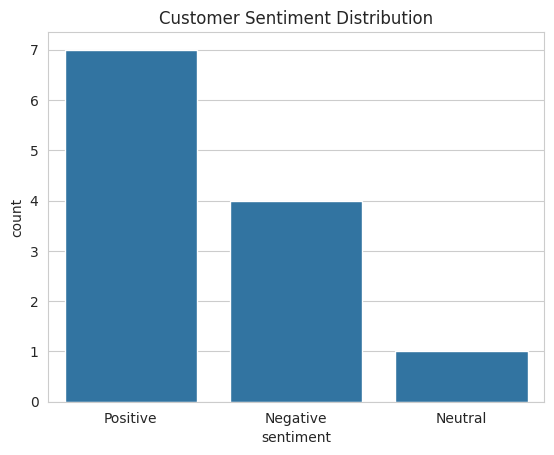

In [6]:
# Visualization
plt.figure()
sns.countplot(x='sentiment', data=df)
plt.title('Customer Sentiment Distribution')
plt.show()

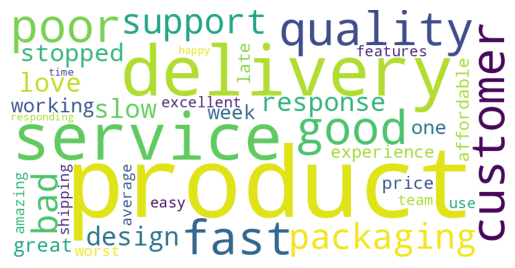

In [7]:
# WordCloud
text = ' '.join(df['clean_reviews'])
wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure()
plt.imshow(wc)
plt.axis('off')
plt.show()